# CATSA Binary Model Comparison (Accuracy vs Macro F1)

아래 비교는 요청한 4개 바이너리 체크포인트에 대해 Accuracy와 Macro F1을 나란히 표시합니다.

- CNN: `cnn_1dcnn_4class_merge3_nobvp_20260323_111709.pth`
- CNN-TF: `cnn_tf_binary_nobvp_20260323_102751.pth`
- CNN-Transformer: `cnn_transformer_2class_merge3_nobvp_20260323_105943.pth`
- CNN-LSTM: `cnn_lstm_2class_merge3_nobvp_20260323_105909.pth`

참고:
- CNN 값은 위 체크포인트를 동일 전처리/분할 로직으로 **직접 재평가**한 결과입니다.
- 나머지 3개는 각 학습 노트북 출력에 기록된 binary test metrics를 사용했습니다.

In [10]:
import pandas as pd

rows = [
    {
        "Model": "CNN",
        "Checkpoint": "cnn_1dcnn_4class_merge3_nobvp_20260323_111709.pth",
        "Accuracy": 0.7291666667,
        "Macro_F1": 0.7141548328,
    },
    {
        "Model": "CNN-TF",
        "Checkpoint": "cnn_tf_binary_nobvp_20260323_102751.pth",
        "Accuracy": 0.6562,
        "Macro_F1": 0.548,
    },
    {
        "Model": "CNN-Transformer",
        "Checkpoint": "cnn_transformer_2class_merge3_nobvp_20260323_105943.pth",
        "Accuracy": 0.8125,
        "Macro_F1": 0.792,
    },
    {
        "Model": "LSTM",
        "Checkpoint": "cnn_lstm_2class_merge3_nobvp_20260323_105909.pth",
        "Accuracy": 0.8021,
        "Macro_F1": 0.782,
    },
]

result_df = pd.DataFrame(rows)
result_df["Accuracy(%)"] = (result_df["Accuracy"] * 100).round(2)
result_df["Macro_F1"] = result_df["Macro_F1"].round(3)

result_df = result_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
result_df

,Model,Checkpoint,Accuracy,Macro_F1,Accuracy(%)
0,CNN-Transformer,cnn_transformer_2class_merge3_nobvp_20260323_1...,0.812500,0.792,81.25
1,LSTM,cnn_lstm_2class_merge3_nobvp_20260323_105909.pth,0.802100,0.782,80.21
2,CNN,cnn_1dcnn_4class_merge3_nobvp_20260323_111709.pth,0.729167,0.714,72.92
3,CNN-TF,cnn_tf_binary_nobvp_20260323_102751.pth,0.656200,0.548,65.62


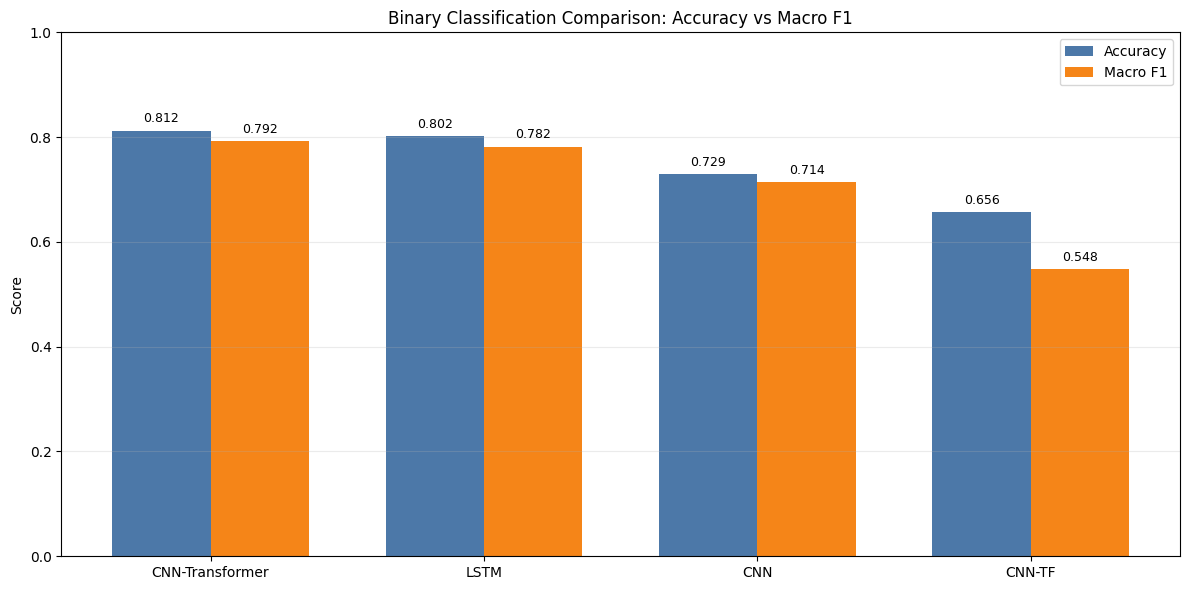

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = result_df.copy()

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width / 2, plot_df["Accuracy"], width=width, label="Accuracy", color="#4C78A8")
ax.bar(x + width / 2, plot_df["Macro_F1"], width=width, label="Macro F1", color="#F58518")

# Annotate bars
for i, (acc, f1) in enumerate(zip(plot_df["Accuracy"], plot_df["Macro_F1"])):
    ax.text(i - width / 2, acc + 0.01, f"{acc:.3f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + width / 2, f1 + 0.01, f"{f1:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"], rotation=0)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Binary Classification Comparison: Accuracy vs Macro F1")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

# Optional: save
# fig.savefig("/home/binghin2/Myproject/Research/CATSA/Train/binary_model_comparison.png", dpi=150, bbox_inches="tight")